# Experiment Analysis

### Hyperparameter space
|Hyperparameter|Type|Range (Original)|Range(Paper)|
|--|--|--|--|
|n_layers |IntDistribution |[1,4]|[1,4]|
|embedding_dim |CategoricalDistribution |[32, 64, 96, 128]|[32, 64, 96, 128, **256**]|
|lr |FloatDistribution (log) |[1e-5, 1e-1]|[1e-5, 1e-1]|
|lambda_val |FloatDistribution (log) |[1e-6, 1e-1]|[1e-6, 1e-1]|
|batch_size |IntDistribution |[512, 2,048]|[512, **4,096**]|
|optimizer |CategoricalDistribution |[Adam, RMSprop, SGD]|[Adam, RMSprop, SGD]|

### 100K Dataset

| Run | Best | Trials | Epochs | Eval<br>every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>reporting | Objective | Prunning | MOO | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | |100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models | Running more epochs to get a better model |
|2 | |200 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose/Strict | All models | Saw overfitting, but didn't have the metric values |
|3 | |200 | 10,000 | 200 | `eval > 3` | Structural | Yes | None | Last  | Recall |Yes|No| Loose/Strict | - Full graph <br> - Dominant sets | Noticed that by running all 10,000 epocs had lower recall|
|4 | |200 | 4,000 | 50 | `eval > 3` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph  | Added early stoppage and best recall reporting to get better models |
|5 | |200 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | Full graph | We should include all reviews, not only the good ones<br>Light GCN is only about interactions. |
|6 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Since last model worked better for Full graph, running for all |
|7 |  |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Trained the random sets based on the best parameters for each the dominant set |
|8 | * |300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |

### 1M Dataset

| Run | Best | Trials | Epochs | Eval every | Filter | Train/test<br>split | Epoch<br>metrics | Stoppage | Optuna<br>objective |  Objective | Prunning | MOO  | Dominant set<br>calculation | Models | Results|
|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|--|
|0 | | 100 | 10,000 | 200 | `eval > 3` | Random | No | None | Last | Recall |Yes|No| Loose | All models  | First run after correcting loss function |
|1 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models | Using iterations from 100K, results seem more consistent |
|2 |  | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | Recall |Yes|No| Loose/Strict | All models |Trained the random sets based on the best parameters <br>for each the dominant set as in the 100K |
|2 | * | 300 | 4,000 | 50 | `eval > 0` | Structural | Yes | Early | Best  | NDCG |No|Yes| Loose/Strict | All models | Added the MOO and focused on NDCG |
 

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import optuna
from optuna.visualization import plot_param_importances, plot_pareto_front
from optuna.importance import get_param_importances
from optuna.trial import TrialState
import seaborn as sns
import datetime

color_map = {'1c1d': '#5CAF50',
             '1c2d': 'skyblue',
             '1c3d': 'salmon',
             'full': 'forestgreen'}

pd.set_option('display.max_columns',None)

#exp_name = 'e_100K'
exp_name = 'e_1M'
version=f'historic_results/{exp_name}/pass_3/'
#version=f'historic_results/sandbox/'
#version=''

/home/paco/gnn-ds/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(f'{version}{exp_name}.parquet')
df = df.sort_values('experiment', ascending=True)
eval_at_epochs = df['epochs_per_eval'].unique()[0]
df.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,optim_time,train_time,infer_time,users,items,train_edges,val_edges,test_edges,epochs_per_eval,multi_objective,objective_metric,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,train_losses,val_losses,recalls,precisions,ndcgs,best_recall,best_precision,best_ndcg,cycle,early_stopping,ds_users,ds_items,ds_time
7,e_1M_1c1dcs,0.581042,0.069236,0.030323,0.061946,0.579470,0.073398,0.032955,0.067251,6378.876046,23.478655,0.859617,6036,3680,190231,97383,97383,50,True,ndcg,1,32,0.000443,0.000182,959,RMSprop,"[0.6918137669563293, 0.6907261610031128, 0.689...","[0.6908207535743713, 0.6903887987136841, 0.689...","[0.004958971176700848, 0.005362269426897463, 0...","[0.00445364238410596, 0.004544701986754968, 0....","[0.005599742501994953, 0.005829329728658743, 0...",0.069051,0.030323,0.062029,1550,True,3156.0,1584.0,2363.87802
8,e_1M_1c1dcs_rand1,0.423530,0.056396,0.035422,0.051078,0.420489,0.061863,0.039081,0.055871,5074.677351,19.052879,0.878864,6036,3470,190231,97383,97383,50,True,ndcg,1,128,0.000561,0.001781,1091,RMSprop,"[0.6946476697921753, 0.6915709972381592, 0.689...","[0.6900469660758972, 0.6889535784721375, 0.687...","[0.005011382014550244, 0.0047943207648427875, ...","[0.004105960264900663, 0.004130794701986755, 0...","[0.005101186525249048, 0.005152372268770528, 0...",0.060227,0.036705,0.053952,1100,True,NaN,NaN,NaN
9,e_1M_1c1dcs_rand2,0.521839,0.064264,0.038320,0.055941,0.518253,0.073030,0.042848,0.064247,4745.051138,36.947319,1.057278,6036,3470,190231,97383,97383,50,True,ndcg,1,64,0.000339,0.009700,1780,RMSprop,"[0.7099766135215759, 0.7069370150566101, 0.705...","[0.7066614031791687, 0.7052685618400574, 0.704...","[0.004875304392426872, 0.004303112375516808, 0...","[0.0040562913907284765, 0.0036175496688741725,...","[0.005036103591881421, 0.004408848820791339, 0...",0.064760,0.038394,0.056294,2950,True,NaN,NaN,NaN
10,e_1M_1c1dcs_rand3,0.424062,0.062295,0.037492,0.054848,0.420339,0.069917,0.041697,0.061448,4488.788779,20.560042,1.050485,6036,3470,190231,97383,97383,50,True,ndcg,1,128,0.000591,0.000987,831,RMSprop,"[0.6935111880302429, 0.6896597743034363, 0.687...","[0.6869753003120422, 0.685951828956604, 0.6844...","[0.004696059313143724, 0.004905124474745582, 0...","[0.0040149006622516555, 0.004105960264900663, ...","[0.004829781476410246, 0.005145807883755547, 0...",0.063294,0.037773,0.055780,1250,True,NaN,NaN,NaN
11,e_1M_1c1dcs_rand4,0.579523,0.058739,0.036672,0.049874,0.577126,0.065719,0.041225,0.056925,5052.852506,17.478572,0.873280,6036,3470,190231,97383,97383,50,True,ndcg,1,32,0.000684,0.028432,571,RMSprop,"[0.7187602519989014, 0.7131701707839966, 0.709...","[0.7177191972732544, 0.7119712233543396, 0.709...","[0.004958673180651038, 0.00308907599879151, 0....","[0.004130794701986755, 0.002673841059602649, 0...","[0.005247394482803083, 0.003183776112756834, 0...",0.070872,0.040646,0.059893,1150,True,NaN,NaN,NaN


## Losses for "Strict" DS Runs

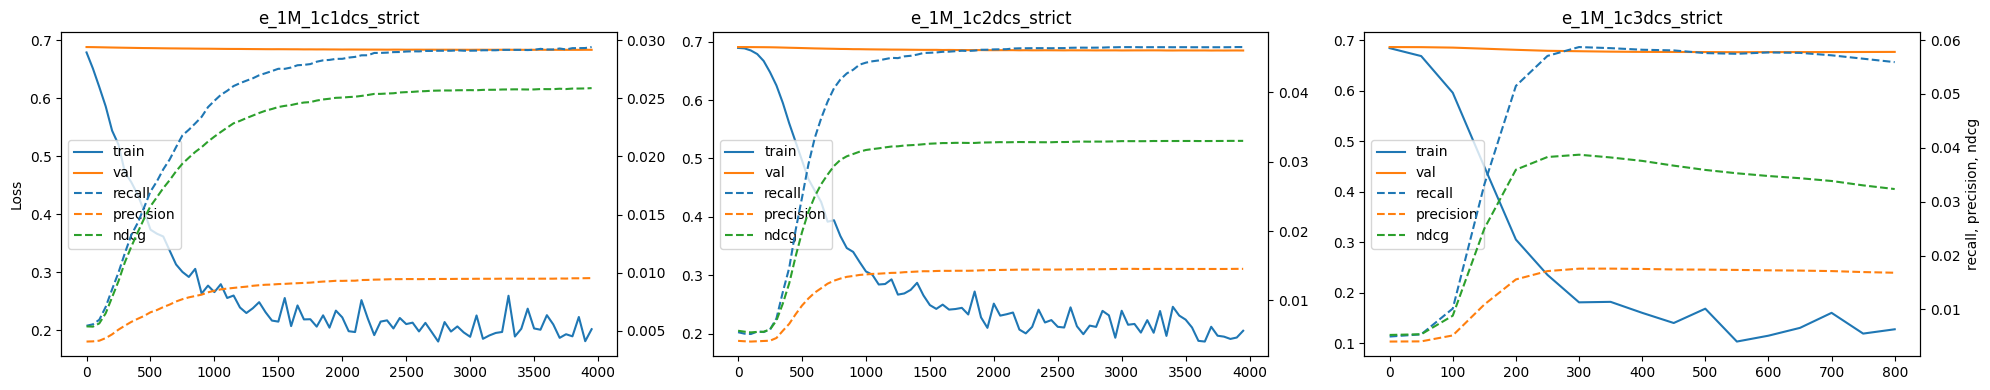

In [3]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')
    
    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict.png')
plt.show()


## Losses for non-"Strict" DS and non-Random Runs

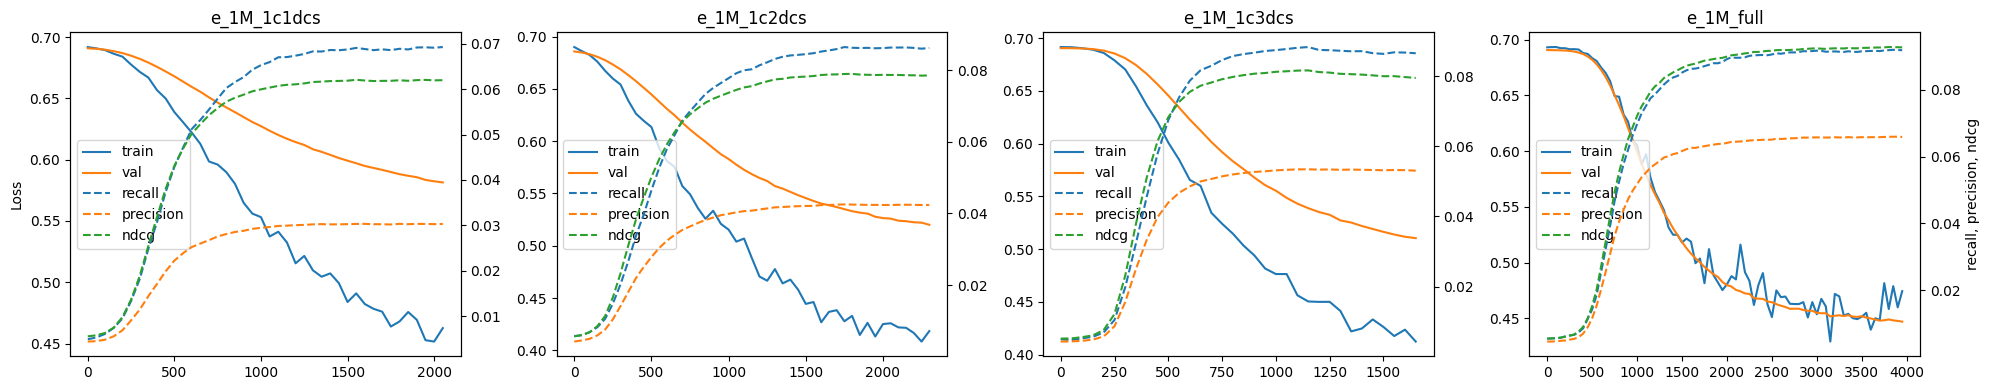

In [4]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & ~df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(20,4))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(1,total_exp,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose.png')
plt.show()

## Random runs losses for non-strict runs

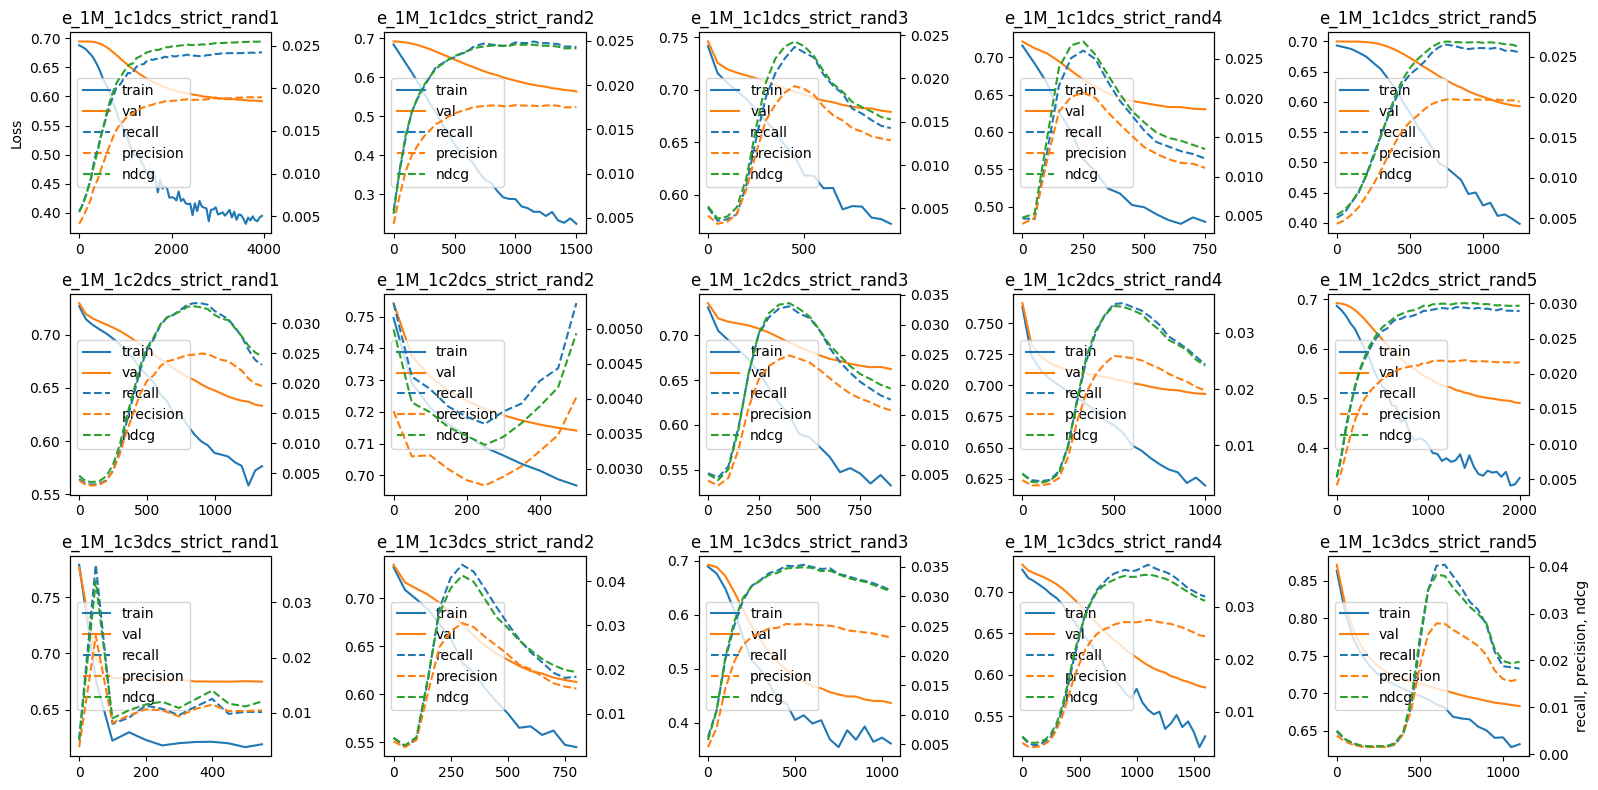

In [5]:
experiments_ran_non_strict = df[df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_strict_rand.png')
plt.show()

## Random runs losses for non-strict runs

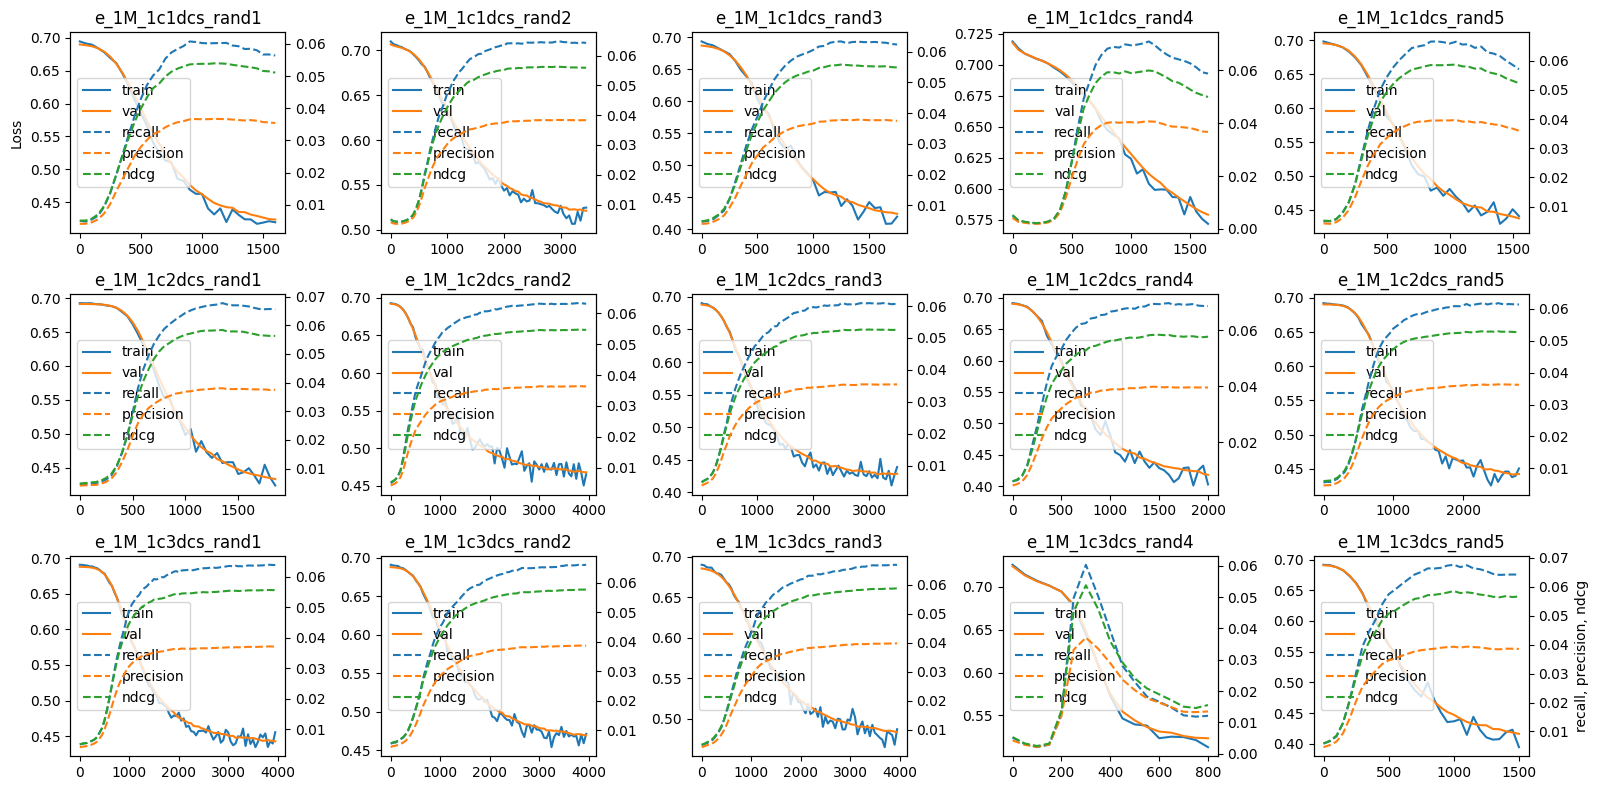

In [6]:
experiments_ran_non_strict = df[~df['experiment'].str.contains('_strict') & df['experiment'].str.contains('_rand')]
total_exp = len(experiments_ran_non_strict)
plt.figure(figsize=(16,8))

metrics_cols = ['recalls','precisions','ndcgs']

for i in range(total_exp):
    record = experiments_ran_non_strict.iloc[i]
    ax1 = plt.subplot(3,5,i+1)
    plt.title(record['experiment'])
    x_values = [x*eval_at_epochs for x in range(0,len(record['train_losses']))]
    ax1.plot(x_values, record['train_losses'], label='train')
    ax1.plot(x_values, record['val_losses'], label='val')

    if i==0:
        plt.ylabel('Loss')

    ax2 = ax1.twinx()

    for col in metrics_cols:
        if col in experiments_ran_non_strict.columns:
            ax2.plot(x_values, record[col], label=col[:-1], linestyle='--')

    if i==total_exp-1:
        plt.ylabel(', '.join(x[:-1] for x in metrics_cols))

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.tight_layout()
plt.savefig(version+'loss_metrics_loose_rand.png')
plt.show()

## Trial analysis

In [7]:
experiments_ran = df[~df['experiment'].str.contains('_rand')]['experiment']

data =  {}
trials = {}
ranges = ''

objective_metric = df['objective_metric'].unique()[0]
objective_metric = objective_metric if objective_metric is not None else 'recall'
objective_metric_dict = {'recall':0, 'precision':1, 'ndcg':2}

for exp in experiments_ran:
    study = optuna.load_study(study_name=f'Study_{exp}', storage=f'sqlite:///{version}{exp_name}.sqlite3')
    plot_param_importances(study)

    importance = get_param_importances(study, target=lambda t: t.values[objective_metric_dict[objective_metric]]) #added target for multi-objective
    params = {}
    for param, value in importance.items():
        #print(f"{param}: {value}")
        params[param] = value

    ranges = study.get_trials()[0].distributions

    pruned_trials = len(study.get_trials(deepcopy=False, states=[TrialState.PRUNED]))
    complete_trials = len(study.get_trials(deepcopy=False, states=[TrialState.COMPLETE]))

    data[exp] = params
    trials[exp] = {'pruned':pruned_trials, 'complete':complete_trials}

importances_df = pd.DataFrame.from_dict(data, orient='index')
trials_df = pd.DataFrame.from_dict(trials, orient='index')
importances_df

,optimizer,n_layers,lr,lambda_val,embedding_dim,batch_size
e_1M_1c1dcs,0.758011,0.126960,0.068094,0.026135,0.016137,0.004664
e_1M_1c1dcs_strict,0.109519,0.115465,0.205474,0.089255,0.289544,0.190742
e_1M_1c2dcs,0.663459,0.038250,0.058968,0.204135,0.010485,0.024701
e_1M_1c2dcs_strict,0.079224,0.218752,0.178534,0.070465,0.087108,0.365917
e_1M_1c3dcs,0.711546,0.082363,0.117777,0.044649,0.015818,0.027848
e_1M_1c3dcs_strict,0.087762,0.049699,0.159967,0.274083,0.091014,0.337475
e_1M_full,0.864320,0.087135,0.018297,0.006838,0.007195,0.016216


In [8]:
studies = optuna.get_all_study_names(storage=f'sqlite:///{version}{exp_name}.sqlite3')

results = {}
for study_name in studies:
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')
    is_multi = len(study.directions) > 1

    trials = {}
    for trial in study.get_trials():
        parameters = trial.params
        parameters.update({'status': trial.state})
        parameters.update({'value': trial.values if is_multi else trial.value})
        parameters.update({'multi_objective':is_multi})
        trials[trial.number] = parameters

    results[study_name] = trials

flattened_data = {
    (outer_key, inner_key): values 
    for outer_key, inner_dict in results.items() 
    for inner_key, values in inner_dict.items()
}
flattened_data

trials_params = pd.DataFrame.from_dict(flattened_data, orient='index').reset_index(names=['study','trial'])
trials_params['status'] = trials_params['status'].map({x: str(TrialState(x)).split('.')[1].lower() for x in range(0,5)})
trials_params.head()


,study,trial,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer,status,value,multi_objective
0,Study_e_1M_full,0,3,128,0.000070,0.000025,864,SGD,complete,"[0.00610804365778935, 0.004735099337748344, 0....",True
1,Study_e_1M_full,1,2,256,0.000082,0.000010,3551,SGD,complete,"[0.005336026866457948, 0.004594370860927152, 0...",True
2,Study_e_1M_full,2,2,128,0.000037,0.057403,1593,Adam,complete,"[0.005653097804574563, 0.004610927152317881, 0...",True
3,Study_e_1M_full,3,2,64,0.000017,0.000018,3803,RMSprop,complete,"[0.006111978462134492, 0.004801324503311258, 0...",True
4,Study_e_1M_full,4,3,32,0.079703,0.000120,791,SGD,complete,"[0.005130245149905195, 0.004321192052980133, 0...",True


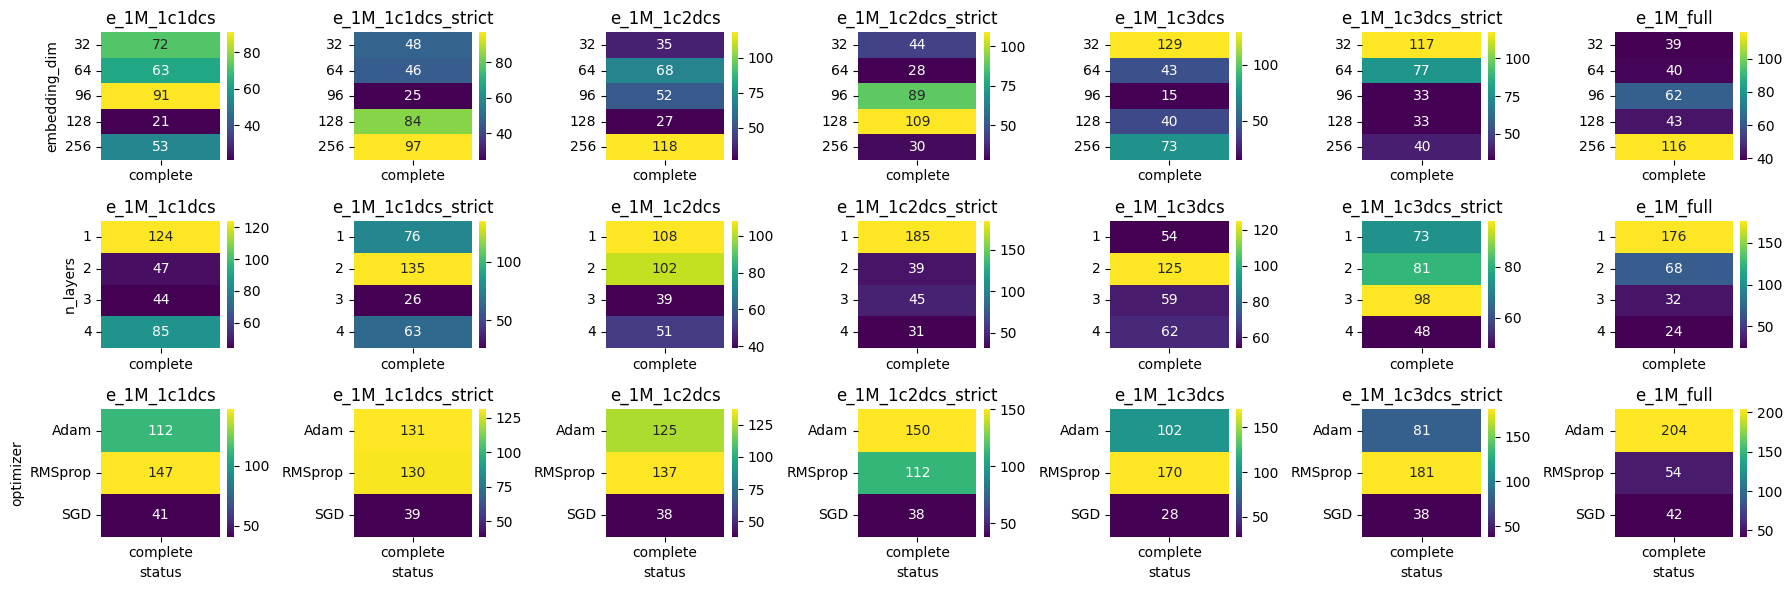

In [9]:
plt.figure(figsize=(18,6))
hyper_params = ['embedding_dim','n_layers','optimizer']

for j,param in enumerate(hyper_params):
    df_t = trials_params.groupby(['study','status',param]).count().reset_index()
    df_t = df_t[~df_t['study'].str.contains('_rand')]

    for i, study in enumerate(df_t['study'].unique()):
        plt.subplot(len(hyper_params),df_t['study'].nunique(),j*(df_t['study'].nunique())+i+1)
        plt.title(study[len('Study_'):])
        sub_df = df_t[df_t['study']==study]
        ax = sns.heatmap(sub_df.pivot(index=param, columns='status', values='trial'), cmap='viridis', annot=True, fmt='.0f')
        plt.yticks(rotation=0)

        if i != 0:
            ax.set(ylabel=None)
        
        if j != len(hyper_params)-1:
            ax.set(xlabel=None)

plt.tight_layout()
plt.savefig(version+'trials_hyperparmeters.png')
plt.show()

In [10]:
study_name = f'Study_{exp_name}_full'

if trials_params['multi_objective'].unique()[0]:
    print('Plotting pareto front ...')
    study = optuna.load_study(study_name=study_name, storage=f'sqlite:///{version}{exp_name}.sqlite3')

    best_trials = study.best_trials
    for trial in best_trials:
        print(f"Trial #{trial.number}: Values={trial.values}, Params={trial.params}")

    fig = plot_pareto_front(study, target_names=["Recall", "Precision","NDCG"])
    fig.update_layout(title=f"3D Pareto Front: {study_name}", width=800, height=800)
    fig.show()
else:
    print('Not a multi-objective run ... ')


Plotting pareto front ...
Trial #251: Values=[0.09249267605045637, 0.06596854304635762, 0.09197312603290791], Params={'n_layers': 1, 'embedding_dim': 32, 'lr': 0.0007928857958215832, 'lambda_val': 1.207883913872658e-06, 'batch_size': 576, 'optimizer': 'Adam'}


In [60]:
ranges

{'n_layers': IntDistribution(high=4, log=False, low=1, step=1),
 'embedding_dim': CategoricalDistribution(choices=(32, 64, 96, 128, 256)),
 'lr': FloatDistribution(high=0.1, log=True, low=1e-05, step=None),
 'lambda_val': FloatDistribution(high=0.1, log=True, low=1e-06, step=None),
 'batch_size': IntDistribution(high=4096, log=False, low=512, step=1),
 'optimizer': CategoricalDistribution(choices=('Adam', 'RMSprop', 'SGD'))}

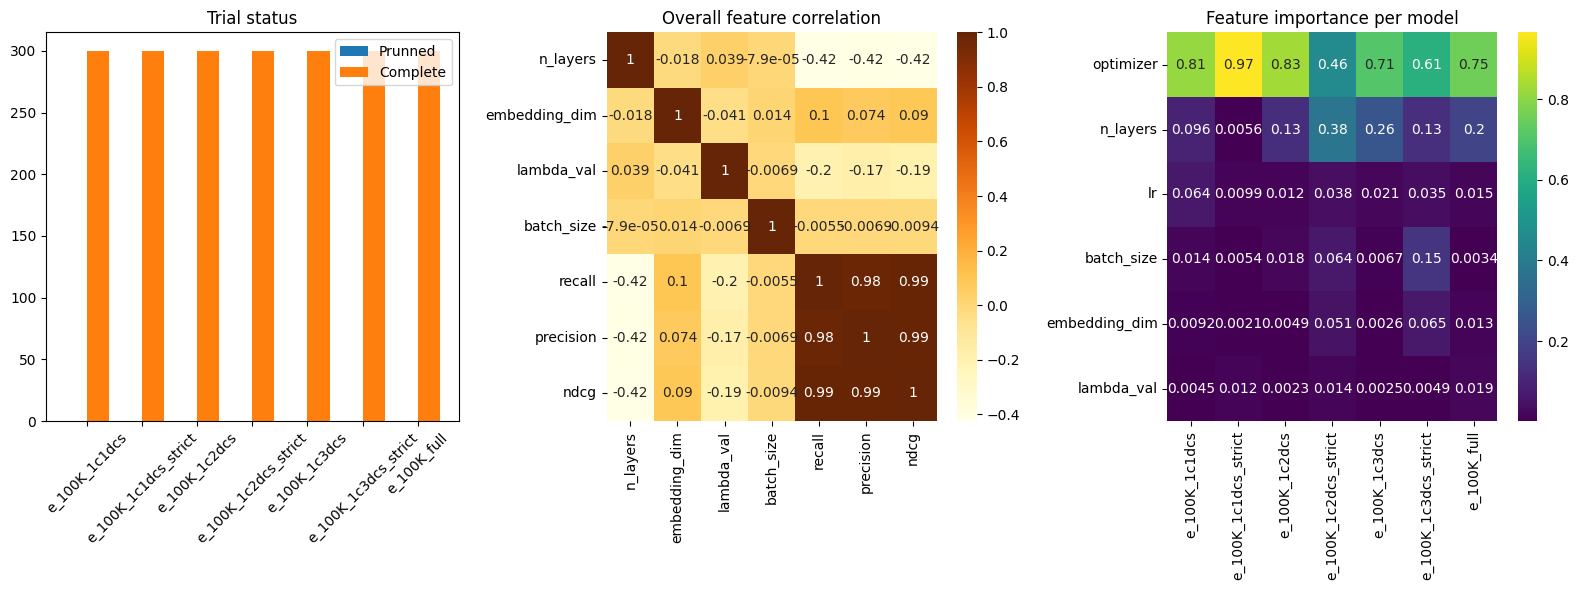

In [61]:
x = np.arange(len(trials_df))
width = 0.4

plt.figure(figsize=(16,6))
plt.subplot(1,3,1)
plt.bar(x = x, width = width, height=trials_df['pruned'], label='Prunned')
plt.bar(x = x+width, width = width, height=trials_df['complete'], label='Complete')

plt.legend()
plt.xticks(x+width/2, trials_df.index, rotation=45)

plt.title('Trial status')

plt.subplot(1,3,2)
if trials_params['multi_objective'].unique()[0]:
    sns.heatmap(trials_params.assign(recall=trials_params['value'].apply(pd.Series)[0], precision=trials_params['value'].apply(pd.Series)[1], ndcg=trials_params['value'].apply(pd.Series)[2])[['n_layers','embedding_dim','lambda_val','batch_size','recall','precision','ndcg']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')
else:
    sns.heatmap(trials_params[['n_layers','embedding_dim','lambda_val','batch_size','value']].corr(), cmap='YlOrBr', annot=True)
    plt.title('Overall feature correlation')

plt.subplot(1,3,3)
sns.heatmap(importances_df.T, annot=True, cmap='viridis')
plt.title('Feature importance per model')

plt.tight_layout()
plt.savefig(version+'trials_feature_importance.png')
plt.show()

## Visualizations

In [62]:
key = ['experiment']
val_features = ['val_loss','val_recall','val_precision','val_ndcg' ]
test_features = ['test_loss','test_recall','test_precision','test_ndcg']
train_features = ['best_recall','cycle','early_stopping'] if "best_recall" in df.columns else []
time_features = ['optim_time','train_time','infer_time'] + (['ds_time'] if "ds_time" in df.columns else [])
edge_features =  ['train_edges','ds_users', 'ds_items']
numerical_features = val_features + test_features + train_features 
categorical_features = ['n_layers','embedding_dim','lr','lambda_val','batch_size', 'optimizer']

cleanup_columns = ['ds_time','ds_users','ds_items']
for col in cleanup_columns:
    if col not in df:
        df[col] = np.nan

random_experiments_stats = df.copy()
random_experiments_stats = random_experiments_stats[key + numerical_features + time_features + edge_features + categorical_features]
random_experiments_stats['experiment'] = random_experiments_stats['experiment'].apply(lambda x: x[len(exp_name)+1:-1] if '_rand' in x else x[len(exp_name)+1:])
color_dict = { exp:color_map[exp[0:4]] for exp in random_experiments_stats['experiment'].unique()}
random_experiments_stats.head()

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,optim_time,train_time,infer_time,ds_time,train_edges,ds_users,ds_items,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
7,1c1dcs,0.346382,0.050714,0.040738,0.056046,0.349949,0.056923,0.046885,0.063436,0.057651,900,True,2111.864472,4.238313,0.090695,20.437767,65267,303.0,232.0,1,64,0.000513,0.002743,2427,RMSprop
8,1c1dcs_rand,0.283489,0.106351,0.050820,0.089819,0.279020,0.116738,0.057131,0.097914,0.108118,1300,True,1960.147073,5.591445,0.095832,NaN,65267,NaN,NaN,1,128,0.000505,0.000129,1510,RMSprop
9,1c1dcs_rand,0.264115,0.115966,0.051066,0.086456,0.258695,0.117847,0.054836,0.097500,0.123866,750,True,1973.238387,4.726929,0.096753,NaN,65267,NaN,NaN,1,256,0.000520,0.000353,2386,Adam
10,1c1dcs_rand,0.240874,0.101410,0.045246,0.075709,0.244935,0.105243,0.048689,0.082482,0.117954,700,True,2169.676961,4.408539,0.096935,NaN,65267,NaN,NaN,1,256,0.000664,0.000009,2183,Adam
11,1c1dcs_rand,0.290651,0.115740,0.053525,0.094265,0.299438,0.108752,0.054590,0.091426,0.115133,1550,True,2011.061679,6.392260,0.095547,NaN,65267,NaN,NaN,1,128,0.000413,0.000049,1834,Adam


In [63]:
total_run = random_experiments_stats[time_features].sum().sum()
print('Total run time: ', str(datetime.timedelta(seconds=total_run)))

Total run time:  20:20:53.500758


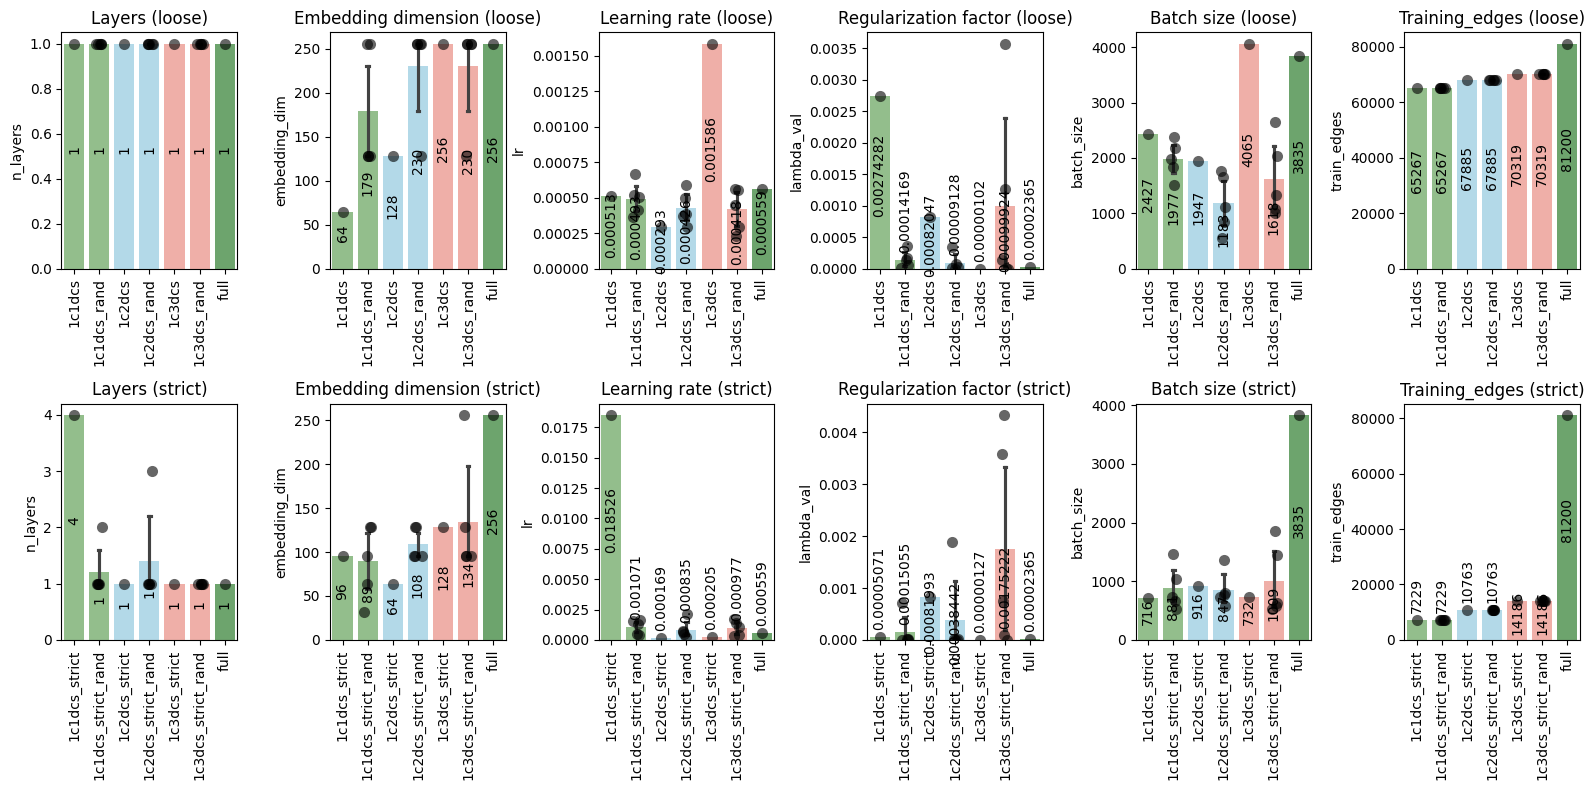

In [64]:
plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))

cols = ['n_layers','embedding_dim','lr','batch_size']

for j,strict in enumerate([False, True]):
    for i,metric in enumerate(plots):
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)

        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)


plt.tight_layout()
plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()

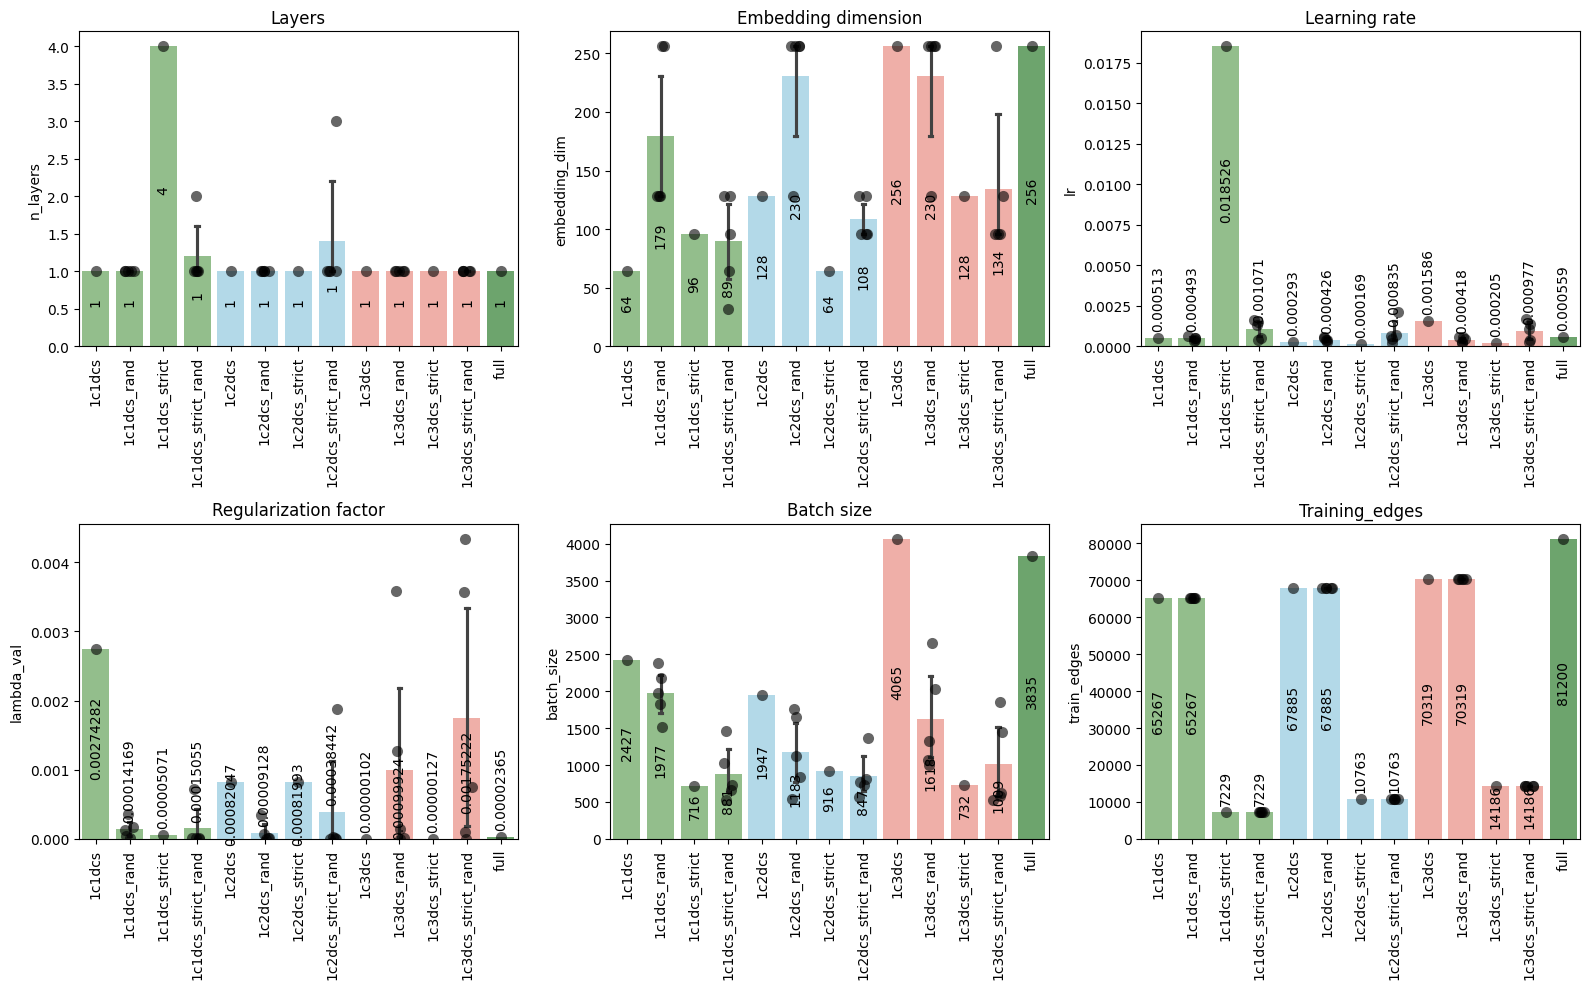

In [65]:

new_df = df.copy()
new_df['experiment'] = new_df['experiment'].apply(lambda x: x[len(exp_name)+1:])

plots=['n_layers','embedding_dim','lr', 'lambda_val', 'batch_size','train_edges']
titles=['Layers', 'Embedding dimension', 'Learning rate', 'Regularization factor', 'Batch size','Training_edges']
formats=['%d', '%d', '%.6f', '%.8f', '%d', '%d']

n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

plt.figure(figsize=(16,10))

cols = ['n_layers','embedding_dim','lr','batch_size']

for i,metric in enumerate(plots):
    plt.subplot(n_plots_height,n_plots_wide,i+1)

    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_hyperparmeters.png')
plt.show()


In [66]:
aggregations = { x : ['mean','std'] for x in numerical_features + time_features}
aggregations.update({ x : ['mean'] for x in edge_features} )
aggregations.update({ x : ['unique'] for x in categorical_features} )


result = random_experiments_stats.groupby(key, as_index=False).agg(aggregations)
result.columns = ["_".join(col).strip() for col in result.columns.values]
result.columns = [ x[:-1] if x[-1]== '_' else x for x in result.columns]
result.fillna(0, inplace=True)
result.head()

,experiment,val_loss_mean,val_loss_std,val_recall_mean,val_recall_std,val_precision_mean,val_precision_std,val_ndcg_mean,val_ndcg_std,test_loss_mean,test_loss_std,test_recall_mean,test_recall_std,test_precision_mean,test_precision_std,test_ndcg_mean,test_ndcg_std,best_recall_mean,best_recall_std,cycle_mean,cycle_std,early_stopping_mean,early_stopping_std,optim_time_mean,optim_time_std,train_time_mean,train_time_std,infer_time_mean,infer_time_std,ds_time_mean,ds_time_std,train_edges_mean,ds_users_mean,ds_items_mean,n_layers_unique,embedding_dim_unique,lr_unique,lambda_val_unique,batch_size_unique,optimizer_unique
0,1c1dcs,0.346382,0.000000,0.050714,0.000000,0.040738,0.000000,0.056046,0.000000,0.349949,0.00000,0.056923,0.000000,0.046885,0.000000,0.063436,0.000000,0.057651,0.000000,900.0,0.000000,1.0,0.0,2111.864472,0.000000,4.238313,0.000000,0.090695,0.000000,20.437767,0.0,65267.0,303.0,232.0,[1],[64],[0.0005134970540789423],[0.0027428171281445477],[2427],[RMSprop]
1,1c1dcs_rand,0.275279,0.022888,0.110436,0.006365,0.051066,0.003639,0.088194,0.007762,0.276779,0.02493,0.111865,0.005346,0.054656,0.003646,0.093077,0.006459,0.115657,0.005826,1150.0,398.434436,1.0,0.0,2031.545031,83.878899,5.430010,0.844209,0.096433,0.000697,0.000000,0.0,65267.0,0.0,0.0,[1],"[128, 256]","[0.0005051991365347398, 0.0005201459519511334,...","[0.00012928174782861758, 0.0003533912900666162...","[1510, 2386, 2183, 1834, 1976]","[RMSprop, Adam]"
2,1c1dcs_strict,0.560036,0.000000,0.017587,0.000000,0.015000,0.000000,0.018624,0.000000,0.569235,0.00000,0.024957,0.000000,0.018689,0.000000,0.027265,0.000000,0.017891,0.000000,1750.0,0.000000,1.0,0.0,1914.439840,0.000000,6.480678,0.000000,0.082342,0.000000,20.437767,0.0,7229.0,303.0,232.0,[4],[96],[0.01852608372473555],[5.071290024292256e-05],[716],[RMSprop]
3,1c1dcs_strict_rand,0.358053,0.046132,0.029653,0.004377,0.017984,0.001690,0.026661,0.003366,0.354660,0.04694,0.036352,0.006720,0.020262,0.002303,0.030924,0.005459,0.033247,0.001679,980.0,941.142922,1.0,0.0,1613.333404,148.559774,3.960462,2.445604,0.086277,0.001743,0.000000,0.0,7229.0,0.0,0.0,"[1, 2]","[64, 128, 96, 32]","[0.0016072373570504854, 0.0004975305503445845,...","[1.0986329485253682e-05, 0.0007172417291421626...","[1457, 521, 1031, 733, 664]","[RMSprop, Adam]"
4,1c2dcs,0.333510,0.000000,0.081610,0.000000,0.050492,0.000000,0.076072,0.000000,0.332764,0.00000,0.079733,0.000000,0.055410,0.000000,0.082948,0.000000,0.080685,0.000000,1400.0,0.000000,1.0,0.0,2486.213514,0.000000,5.226160,0.000000,0.094530,0.000000,25.037814,0.0,67885.0,324.0,3679.0,[1],[128],[0.00029334949892417046],[0.0008204739569875012],[1947],[RMSprop]


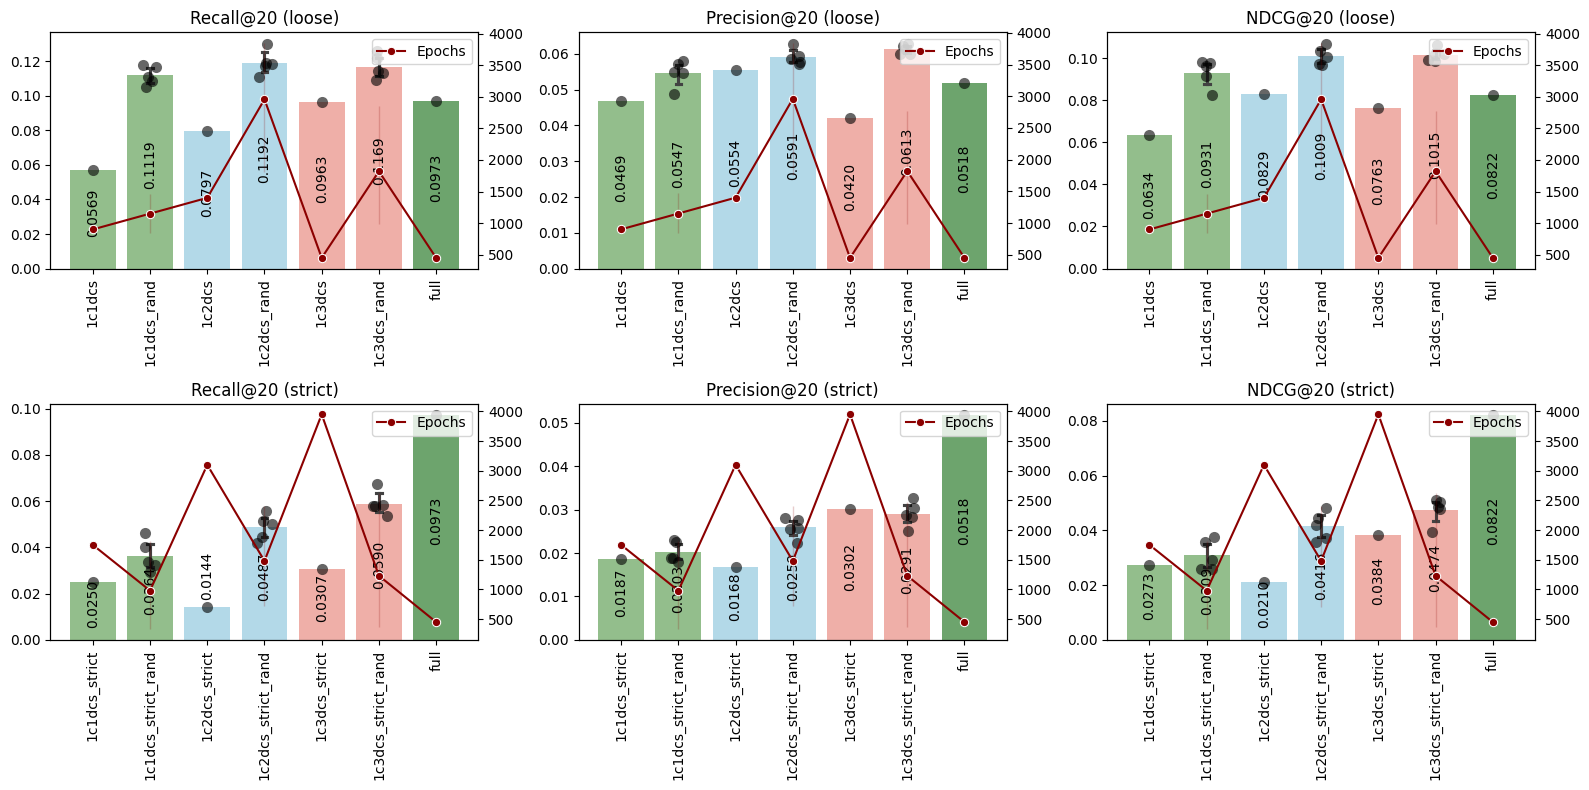

In [67]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):

    for i,metric in enumerate(plots):
        #plt.subplot(1,len(plots),i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]
        
        ax = sns.barplot(data = subset_df, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        sns.stripplot(data=subset_df, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
        plt.ylabel('')
        plt.xlabel('')
        plt.xticks(rotation=90)

        ax2 = ax.twinx()
        #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
        if 'cycle' in subset_df.columns:
            sns.lineplot(data=subset_df, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
            ax2.set_ylabel('Training epochs')

        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.ylabel('')
        plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(version+'experiments_metrics.png')
plt.show()

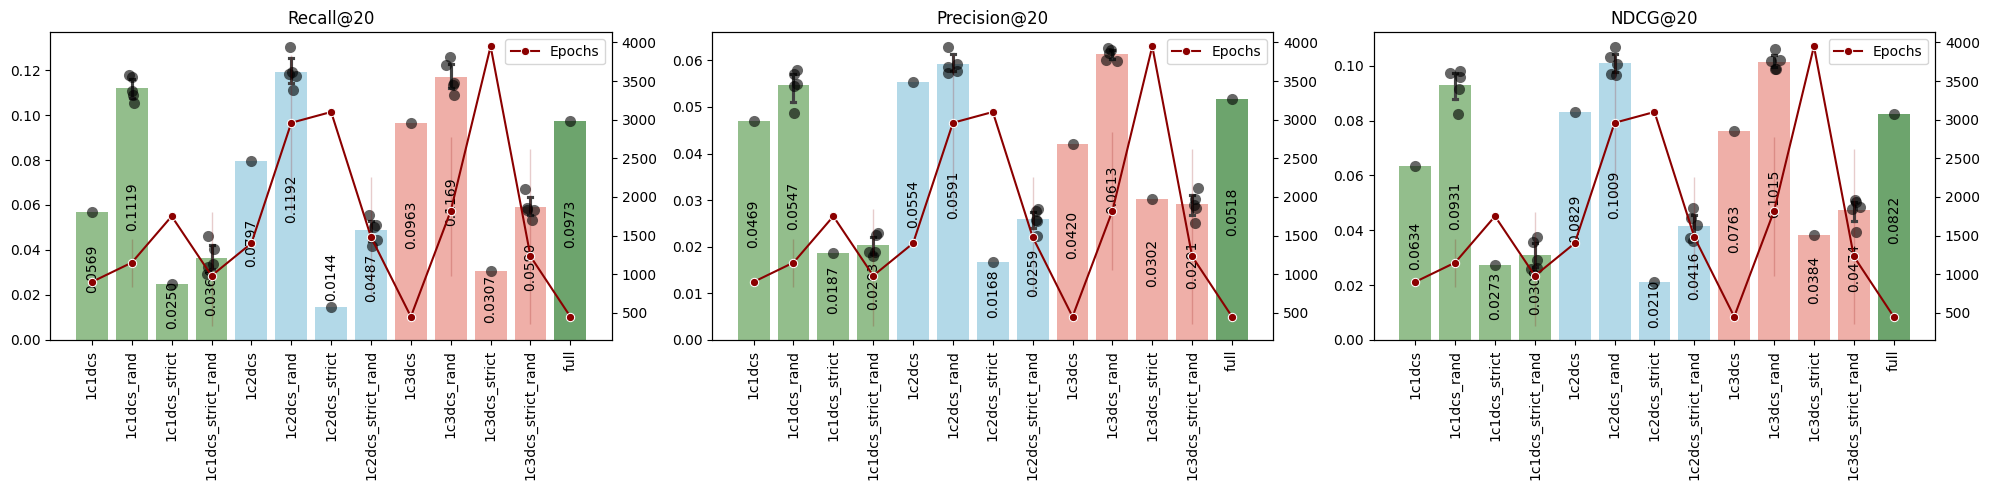

In [68]:
plots=['test_recall','test_precision','test_ndcg']
titles=['Recall@20', 'Precision@20', 'NDCG@20']
formats=['%.4f', '%.4f', '%.4f']

plt.figure(figsize=(20,5))

for i,metric in enumerate(plots):
    plt.subplot(1,len(plots),i+1)
    
    ax = sns.barplot(data = random_experiments_stats, x='experiment', y=metric, errorbar=('ci', 95), capsize=0.1, alpha=0.7, palette=color_dict,  hue='experiment', legend=False) #, color=random_experiments_stats['experiment'].str[0:4].map(color_map), capsize=5)
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        ax.bar_label(container, fmt=formats[i], label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    sns.stripplot(data=random_experiments_stats, x='experiment', y=metric, color='black', size=8, alpha=0.6, jitter=0.15)
    plt.ylabel('')
    plt.xlabel('')
    plt.xticks(rotation=90)

    ax2 = ax.twinx()
    #sns.lineplot(data = random_experiments_stats, x='experiment', ax=ax2, y='cycle', errorbar=('ci', 95), alpha=0.7,  hue='experiment', legend=False)
    if 'cycle' in random_experiments_stats.columns:
        sns.lineplot(data=random_experiments_stats, x='experiment', y='cycle', color='darkred', errorbar="ci", marker='o', ax=ax2, sort=False, label='Epochs')
        ax2.set_ylabel('Training epochs')

    plt.title(titles[i])
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=90)

plt.tight_layout()
#plt.savefig(version+'experiments_metrics.png')
plt.show()

<Figure size 1600x1000 with 0 Axes>

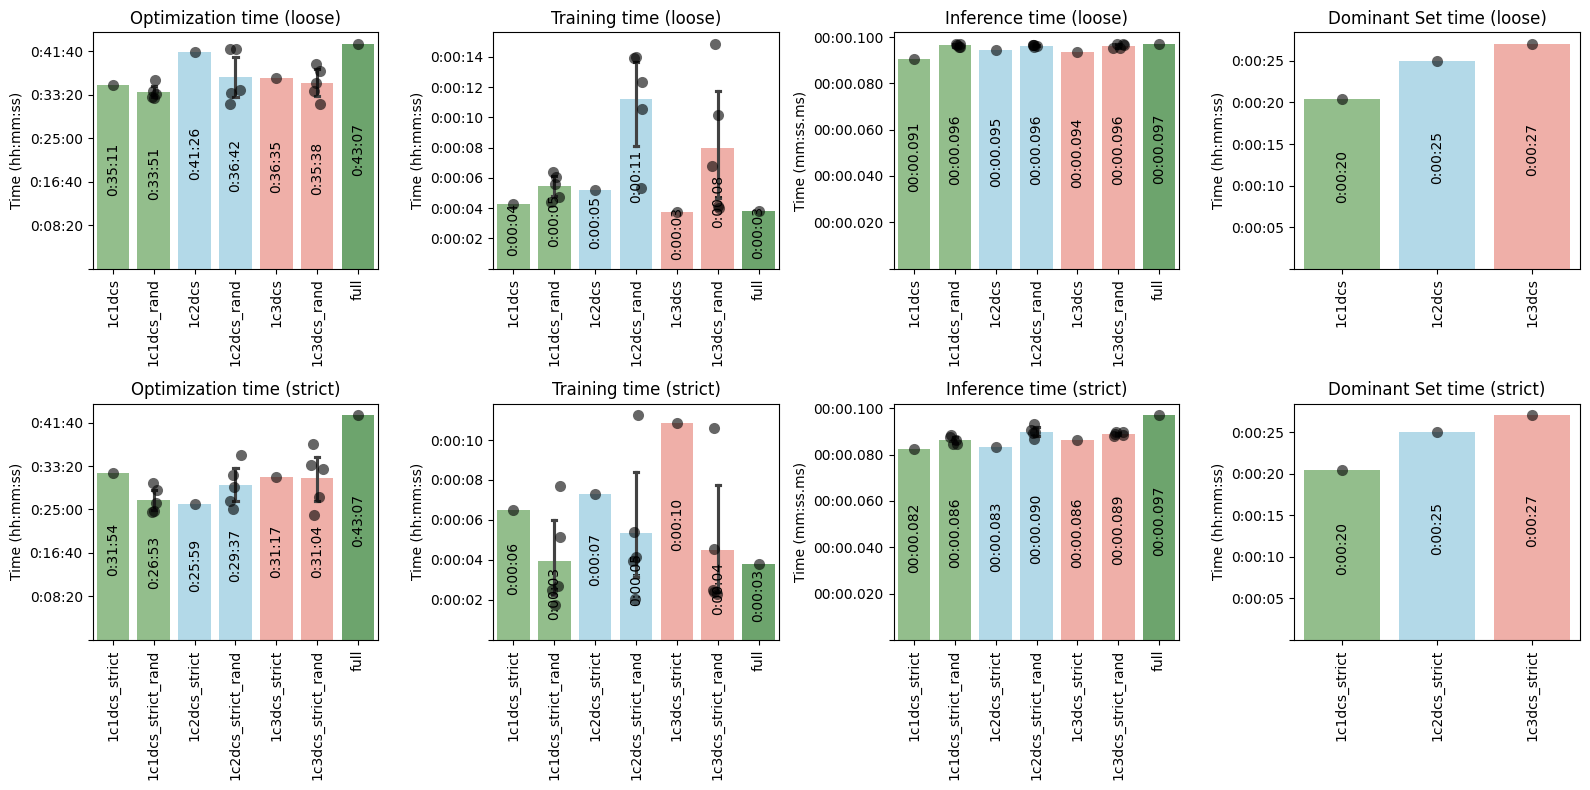

In [69]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value


n_plots_height = 2
n_plots_wide = len(plots)

plt.figure(figsize=(16,8))
#plt.figure(figsize=(20,5))

for j,strict in enumerate([False, True]):
    for i, metric in enumerate(plots):
        #plt.subplot(n_plots_height, n_plots_wide, i+1)
        plt.subplot(n_plots_height,n_plots_wide,j*n_plots_wide + i+1)
        subset_df = random_experiments_stats[(random_experiments_stats['experiment'].str.contains('_strict') == strict) | random_experiments_stats['experiment'].str.contains('full')]

        # Create the barplot
        ax = sns.barplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            errorbar=('ci', 95),
            capsize=0.1, 
            alpha=0.7, 
            palette=color_dict,  
            hue='experiment', 
            legend=False
        ) 

        # --- FIX FOR BAR LABELS ---
        # Iterate through all containers generated by Seaborn's hue
        max_value = np.max([ x.datavalues for x in ax.containers])
        for container in ax.containers:
            # Generate a label list directly from the bar heights in this specific container
            labels = [format_time(val) for val in container.datavalues]
            ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
        # --------------------------


        # Add the stripplot
        sns.stripplot(
            data=subset_df[subset_df[metric]>0], 
            x='experiment', 
            y=metric, 
            color='black', 
            size=8, 
            alpha=0.6, 
            jitter=0.15,
            ax=ax
        )
        
        plt.title(titles[i]+(' (strict)' if strict else ' (loose)'))
        plt.xlabel('')
        plt.xticks(rotation=90)

        # Use the mean of the actual current metric to decide the axis label
        current_mean = subset_df[metric].mean()
        if current_mean < 1:
            plt.ylabel('Time (mm:ss.ms)')
        else:
            plt.ylabel('Time (hh:mm:ss)')
            
        plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
plt.savefig(version+'experiments_times.png')
plt.show()

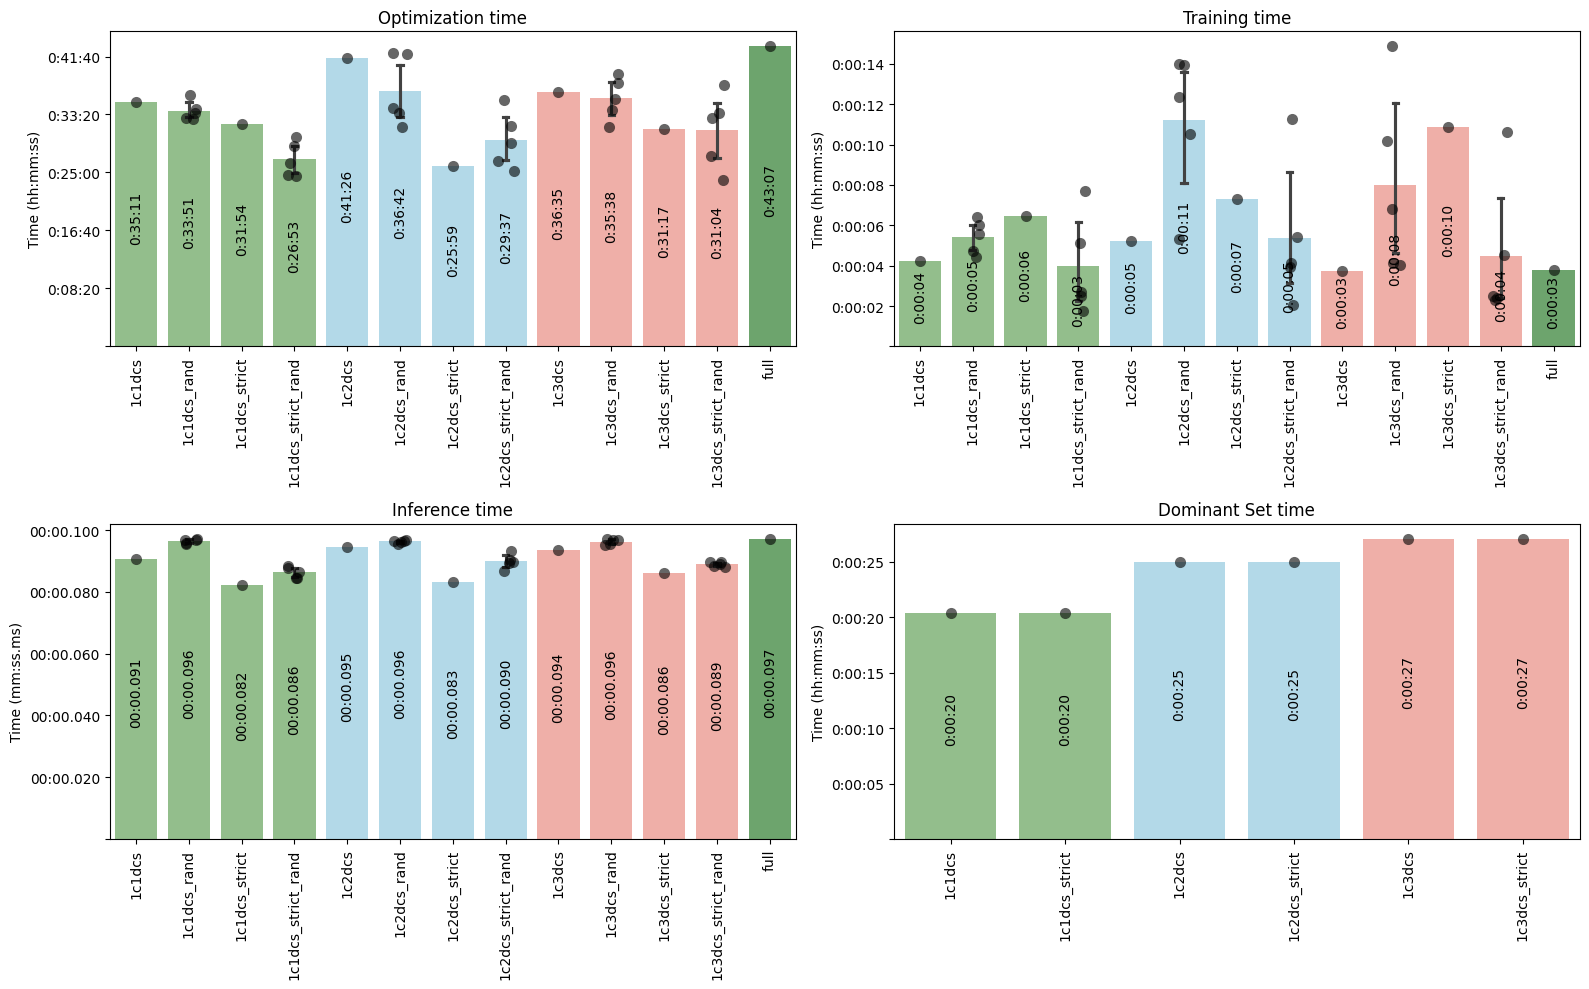

In [70]:
from matplotlib.ticker import FuncFormatter
from datetime import timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plots=time_features #['optim_time','train_time','infer_time'] + ['ds_time'] if 'ds_time' in random_experiments_stats.columns else []
titles=['Optimization time', 'Training time', 'Inference time','Dominant Set time']
# formats=['%d', '%d', '%.4f', '%d', '%d']
colors=[ '#4CAF50','#4CAF50','skyblue','skyblue','salmon','salmon', 'forestgreen']

plt.figure(figsize=(16,10))
n_plots_height = 2
n_plots_wide = len(plots)//n_plots_height if (len(plots)/n_plots_height) % 2 ==1 else len(plots)//n_plots_height

# Added a default value to pos (pos=None) so we can reuse this function for bar labels easily
def format_time(x, pos=None):
    if pd.isna(x) or x <= 0:
        return ""
    if x >= 1:
        value = str(timedelta(seconds=int(x)))
    else:
        m, s = divmod(x, 60)
        value = f"{int(m):02d}:{s:06.3f}"
    return value

for i, metric in enumerate(plots):
    plt.subplot(n_plots_height, n_plots_wide, i+1)

    # Create the barplot
    ax = sns.barplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        errorbar=('ci', 95),
        capsize=0.1, 
        alpha=0.7, 
        palette=color_dict,  
        hue='experiment', 
        legend=False
    ) 

    # --- FIX FOR BAR LABELS ---
    # Iterate through all containers generated by Seaborn's hue
    max_value = np.max([ x.datavalues for x in ax.containers])
    for container in ax.containers:
        # Generate a label list directly from the bar heights in this specific container
        labels = [format_time(val) for val in container.datavalues]
        ax.bar_label(container, labels=labels, label_type='edge' if container.datavalues < max_value/6 else 'center', rotation=90, padding=5)
    # --------------------------


    # Add the stripplot
    sns.stripplot(
        data=random_experiments_stats[random_experiments_stats[metric]>0], 
        x='experiment', 
        y=metric, 
        color='black', 
        size=8, 
        alpha=0.6, 
        jitter=0.15,
        ax=ax
    )
    
    plt.title(titles[i])
    plt.xlabel('')
    plt.xticks(rotation=90)

    # Use the mean of the actual current metric to decide the axis label
    current_mean = random_experiments_stats[metric].mean()
    if current_mean < 1:
        plt.ylabel('Time (mm:ss.ms)')
    else:
        plt.ylabel('Time (hh:mm:ss)')
        
    plt.gca().yaxis.set_major_formatter(FuncFormatter(format_time))

plt.tight_layout()
#plt.savefig(version+'experiments_times.png')
plt.show()

In [71]:
result_viewable = result.copy()

for col in numerical_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: '{:,.4f}'.format(x[col+'_mean']) if x[col+'_std'] ==0 else '{:,.4f}'.format(x[col+'_mean']) + ' \u00B1 ' +  '{:,.4f}'.format(x[col+'_std']), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

for col in time_features:
    result_viewable[col] = result_viewable[[col+'_mean',col+'_std']].apply(lambda x: str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) if x[col+'_std'] ==0 else str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_mean']))) + ' \u00B1 ' +  str(time.strftime("%H:%M:%S", time.gmtime(x[col+'_std']))), axis=1)
    result_viewable.drop([col+'_mean', col+'_std'], axis=1, inplace=True)

result_viewable = result_viewable[key + numerical_features + [x +'_mean' for x in edge_features] + time_features + [x +'_unique' for x in categorical_features] ]


for token in ['_unique','_mean']:
    rename_dict = { x : x[:-len(token)] if token in x else x for x in result_viewable.columns }
    result_viewable.rename(rename_dict, axis=1, inplace=True)


In [72]:
result_viewable

,experiment,val_loss,val_recall,val_precision,val_ndcg,test_loss,test_recall,test_precision,test_ndcg,best_recall,cycle,early_stopping,train_edges,ds_users,ds_items,optim_time,train_time,infer_time,ds_time,n_layers,embedding_dim,lr,lambda_val,batch_size,optimizer
0,1c1dcs,0.3464,0.0507,0.0407,0.0560,0.3499,0.0569,0.0469,0.0634,0.0577,900.0000,1.0000,65267.0,303.0,232.0,00:35:11,00:00:04,00:00:00,00:00:20,[1],[64],[0.0005134970540789423],[0.0027428171281445477],[2427],[RMSprop]
1,1c1dcs_rand,0.2753 ± 0.0229,0.1104 ± 0.0064,0.0511 ± 0.0036,0.0882 ± 0.0078,0.2768 ± 0.0249,0.1119 ± 0.0053,0.0547 ± 0.0036,0.0931 ± 0.0065,0.1157 ± 0.0058,"1,150.0000 ± 398.4344",1.0000,65267.0,0.0,0.0,00:33:51 ± 00:01:23,00:00:05 ± 00:00:00,00:00:00 ± 00:00:00,00:00:00,[1],"[128, 256]","[0.0005051991365347398, 0.0005201459519511334,...","[0.00012928174782861758, 0.0003533912900666162...","[1510, 2386, 2183, 1834, 1976]","[RMSprop, Adam]"
2,1c1dcs_strict,0.5600,0.0176,0.0150,0.0186,0.5692,0.0250,0.0187,0.0273,0.0179,"1,750.0000",1.0000,7229.0,303.0,232.0,00:31:54,00:00:06,00:00:00,00:00:20,[4],[96],[0.01852608372473555],[5.071290024292256e-05],[716],[RMSprop]
3,1c1dcs_strict_rand,0.3581 ± 0.0461,0.0297 ± 0.0044,0.0180 ± 0.0017,0.0267 ± 0.0034,0.3547 ± 0.0469,0.0364 ± 0.0067,0.0203 ± 0.0023,0.0309 ± 0.0055,0.0332 ± 0.0017,980.0000 ± 941.1429,1.0000,7229.0,0.0,0.0,00:26:53 ± 00:02:28,00:00:03 ± 00:00:02,00:00:00 ± 00:00:00,00:00:00,"[1, 2]","[64, 128, 96, 32]","[0.0016072373570504854, 0.0004975305503445845,...","[1.0986329485253682e-05, 0.0007172417291421626...","[1457, 521, 1031, 733, 664]","[RMSprop, Adam]"
4,1c2dcs,0.3335,0.0816,0.0505,0.0761,0.3328,0.0797,0.0554,0.0829,0.0807,"1,400.0000",1.0000,67885.0,324.0,3679.0,00:41:26,00:00:05,00:00:00,00:00:25,[1],[128],[0.00029334949892417046],[0.0008204739569875012],[1947],[RMSprop]
5,1c2dcs_rand,0.2835 ± 0.0197,0.1128 ± 0.0064,0.0562 ± 0.0027,0.0934 ± 0.0072,0.2814 ± 0.0254,0.1192 ± 0.0070,0.0591 ± 0.0022,0.1009 ± 0.0042,0.1131 ± 0.0066,"2,960.0000 ± 1,324.9528",0.4000 ± 0.5477,67885.0,0.0,0.0,00:36:42 ± 00:05:00,00:00:11 ± 00:00:03,00:00:00 ± 00:00:00,00:00:00,[1],"[256, 128]","[0.0002937451101594534, 0.0003699125560596988,...","[9.736252707896e-06, 0.0003502847300093356, 1....","[841, 544, 1117, 1757, 1658]","[RMSprop, Adam]"
6,1c2dcs_strict,0.6567,0.0131,0.0123,0.0158,0.6556,0.0144,0.0168,0.0210,0.0131,"3,100.0000",1.0000,10763.0,324.0,3679.0,00:25:59,00:00:07,00:00:00,00:00:25,[1],[64],[0.00016882222048828941],[0.0008199279436924151],[916],[RMSprop]
7,1c2dcs_strict_rand,0.3364 ± 0.0365,0.0515 ± 0.0119,0.0246 ± 0.0034,0.0413 ± 0.0082,0.3353 ± 0.0338,0.0487 ± 0.0055,0.0259 ± 0.0023,0.0416 ± 0.0051,0.0555 ± 0.0079,"1,480.0000 ± 1,063.3673",1.0000,10763.0,0.0,0.0,00:29:37 ± 00:04:04,00:00:05 ± 00:00:03,00:00:00 ± 00:00:00,00:00:00,"[1, 3]","[96, 128]","[0.000664690953252874, 0.0004468043875443426, ...","[0.0018827383963552864, 1.4351098259409896e-06...","[724, 1365, 574, 805, 767]","[Adam, RMSprop]"
8,1c3dcs,0.2055,0.0864,0.0402,0.0704,0.1991,0.0963,0.0420,0.0763,0.0974,450.0000,1.0000,70319.0,333.0,4991.0,00:36:35,00:00:03,00:00:00,00:00:27,[1],[256],[0.0015857374591031902],[1.017464054511057e-06],[4065],[Adam]
9,1c3dcs_rand,0.2934 ± 0.0411,0.1144 ± 0.0102,0.0564 ± 0.0013,0.0960 ± 0.0064,0.2932 ± 0.0397,0.1169 ± 0.0068,0.0613 ± 0.0012,0.1015 ± 0.0030,0.1180 ± 0.0129,"1,820.0000 ± 1,169.7222",0.8000 ± 0.4472,70319.0,0.0,0.0,00:35:38 ± 00:03:03,00:00:08 ± 00:00:04,00:00:00 ± 00:00:00,00:00:00,[1],"[256, 128]","[0.000449055427336924, 0.00022696039854004348,...","[0.00013786661592474623, 1.560970908583346e-05...","[1075, 2657, 1333, 999, 2029]","[RMSprop, Adam]"


# Conclusions and actions

## Symptoms
- Model is overfitting, given the train vs. val losses tracking (don't know about the performance metrics, since they haven't been captured.)
- Full graph is converging too fast, but train/val curves are  too far apart, system may have learned "too" quickly

## Suggested actions
- Add tracking for Recall, precision and NDCG (already did after current run.)
- Verify the random sample methods, since it only randomizes using train_test_split from sklearn, but sets may not be fully-connected or even coherent -> Rolando said this before.
    - Nos llevamos aristas siempre que embos nodos esten representados.
- After the right random sample calculate the dominant set from the sample set. --> from here sample random or structure preserving random.
    - The 5 random runs (absolute random), should sample from the random sample ONLY and maybe use a similar algorithm as the full random sample method, 
        - or maybe sample from the main sample with some other variation, limiting the total amount of rows
- Reduce the seach space for certain parameters (embedding_dim, remove the 32 option for instance, layers remove the 4 layers options) --> **Run 300 instances.**
    - Had done this before, but because of th randomization, we may have gotten a bad batch and seems to not converge.


